# Q3 — Incomplete Data (151 angles over 150 deg)
Load ground truth images and evaluate reconstructions for sliding angle windows.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from skimage.transform import radon, iradon

In [4]:
import h5py
def load_mat_h5(path):
    try:
        with h5py.File(path,'r') as f:
            names = list(f.keys())
            for candidate in ['img','I','image','gt','phantom','X']:
                if candidate in f:
                    return np.squeeze(np.array(f[candidate]))
            if len(names)>0:
                return np.squeeze(np.array(f[names[0]]))
    except Exception:
        from scipy.io import loadmat
        data = loadmat(path)
        keys = [k for k in data.keys() if not k.startswith('__')]
        return np.squeeze(data[keys[0]])
im = load_mat_h5('data/assignmentMathImagingRecon_chestCT.mat')
im.shape

(512, 512)

In [5]:
# ensure numeric type
im = im.astype(float)
im.shape

(512, 512)

In [6]:
def compute_best_window(gt, width=151):
    errs = []
    recs = []
    for start in range(0, 181):
        angs = (start + np.arange(0, width)) % 360
        s = radon(gt, theta=angs, circle=True)
        R = iradon(s, theta=angs, filter_name='ramp', circle=True)
        errs.append(np.linalg.norm(gt-R)/np.linalg.norm(gt))
        recs.append(R)
    errs = np.array(errs)
    return errs, recs

In [7]:
errs, recs = compute_best_window(im)
best_idx = np.argmin(errs)
best_idx, errs[best_idx]

c:\Users\rishi\Python\Python3119\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


(63, 0.24356097286105166)

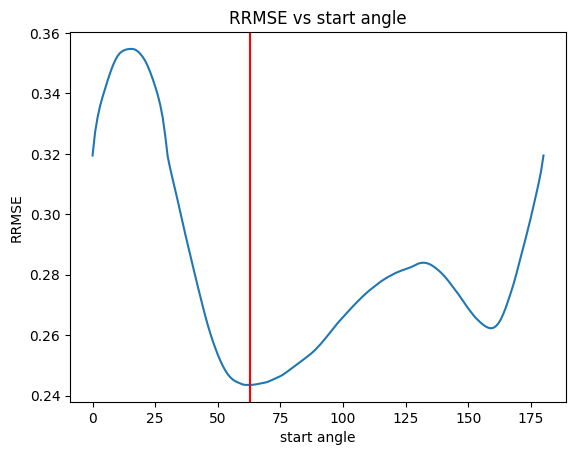

In [8]:
plt.plot(errs); plt.xlabel('start angle'); plt.ylabel('RRMSE'); plt.title('RRMSE vs start angle')
plt.axvline(best_idx, color='r')

Text(0.5, 1.0, 'Best reconstruction start=63')

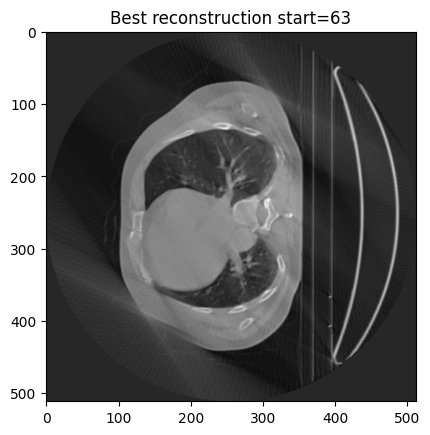

In [9]:
plt.figure(); plt.imshow(recs[best_idx], cmap='gray'); plt.title(f'Best reconstruction start={best_idx}')